In [2]:
!pip install keras keras-tuner tensorflow scikit-learn pandas openpyxl matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import keras
from keras import layers
import keras_tuner as kt

In [4]:
DATA_PATH = "final Data All Exipients.csv"

In [5]:
TARGETS = {
    "Disintegration_Time": "DT",
    "Friability": "FR",
    "Water_Absorption_Ratio": "WAR",
}

In [6]:
MAX_TRIALS       = 30       # number of HP combinations to try
EXECUTIONS       = 2        # runs per trial (reduces variance)
EPOCHS_SEARCH    = 50       # epochs during HP search
EPOCHS_FINAL     = 200      # epochs for final best model
BATCH_SIZE       = 32
VALIDATION_SPLIT = 0.15
TEST_SIZE        = 0.20
RANDOM_STATE     = 42
TUNER_DIR        = "kt_results"   # directory to save tuner logs

In [7]:
def load_data(path: str) -> pd.DataFrame:
    """Load dataset from Excel / CSV / tab-separated file."""
    ext = path.rsplit(".", 1)[-1].lower()
    if ext in ("xlsx", "xls"):
        df = pd.read_excel(path)
    elif ext == "tab":
        df = pd.read_csv(path, sep="\t")
    else:
        df = pd.read_csv(path)
    print(f"✅ Loaded dataset: {df.shape[0]} rows × {df.shape[1]} columns")
    return df

In [8]:
def explore_data(df: pd.DataFrame):
    """Quick EDA printout."""
    print("\n── Column names ─────────────────────────────")
    print(df.columns.tolist())
    print("\n── Data types ───────────────────────────────")
    print(df.dtypes.value_counts())
    print("\n── Missing values (top 10) ──────────────────")
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    print("\n── Numeric statistics ───────────────────────")
    print(df.describe().T)

In [9]:
def identify_target_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """
    Try to find the actual column name in df that matches one of the candidate
    strings (case-insensitive, partial match).
    """
    for col in df.columns:
        for cand in candidates:
            if cand.lower() in col.lower():
                return col
    return None

In [10]:
def preprocess(df: pd.DataFrame, target_col: str):
    """
    1. Drop rows where target is NaN
    2. Drop non-numeric / identifier columns
    3. Impute remaining NaNs with column median
    4. Split features / target
    5. Train-test split
    6. StandardScaler on features
    """
    df = df.copy()

    # Keep only rows with a valid target
    df = df.dropna(subset=[target_col])

    # Drop columns that are fully object type (names, formulation IDs)
    df = df.select_dtypes(include=[np.number])

    # Drop the other two targets to avoid leakage
    target_aliases = [
        "disintegration", "friability", "water absorption",
        "wetting time", "hardness", "drug content",
        "bulk density", "carr", "hausner", "angle of repose"
    ]
    cols_to_drop = [c for c in df.columns
                    if c != target_col and
                    any(alias in c.lower() for alias in target_aliases)]
    df = df.drop(columns=cols_to_drop, errors="ignore")

    # Impute remaining NaNs
    df = df.fillna(df.median(numeric_only=True))

    y = df[target_col].values.astype(np.float32)
    X = df.drop(columns=[target_col]).values.astype(np.float32)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"  Features : {X_train.shape[1]}")
    print(f"  Train    : {X_train.shape[0]} samples")
    print(f"  Test     : {X_test.shape[0]} samples")
    return X_train, X_test, y_train, y_test, scaler

In [11]:
def build_model(hp: kt.HyperParameters, input_dim: int) -> keras.Model:
    """
    Tunable Feed-Forward Neural Network for regression.

    Hyperparameters tuned:
    ─ num_layers        : number of hidden layers (1 – 4)
    ─ units_{i}         : neurons per layer (32 – 512, step 32)
    ─ activation        : relu / elu / tanh
    ─ dropout           : whether to add Dropout
    ─ dropout_rate      : dropout probability (0.1 – 0.5)
    ─ batch_norm        : whether to add BatchNormalization
    ─ learning_rate     : Adam LR (1e-4 – 1e-2, log scale)
    ─ l2_reg            : L2 regularisation (1e-5 – 1e-2, log scale)
    """
    activation  = hp.Choice("activation", ["relu", "elu", "tanh"])
    use_dropout = hp.Boolean("dropout")
    use_bn      = hp.Boolean("batch_norm")
    lr          = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
    l2          = hp.Float("l2_reg", 1e-5, 1e-2, sampling="log")
    num_layers  = hp.Int("num_layers", 1, 4)

    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    for i in range(num_layers):
        units = hp.Int(f"units_{i}", min_value=32, max_value=512, step=32)
        model.add(layers.Dense(
            units,
            activation=activation,
            kernel_regularizer=keras.regularizers.l2(l2),
            kernel_initializer="he_normal" if activation in ("relu","elu") else "glorot_uniform",
        ))
        if use_bn:
            model.add(layers.BatchNormalization())
        if use_dropout:
            drop_rate = hp.Float("dropout_rate", 0.1, 0.5, step=0.1)
            model.add(layers.Dropout(drop_rate))

    # Output: single neuron for regression
    model.add(layers.Dense(1, activation="linear"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model

In [12]:
def run_tuner(X_train, y_train, input_dim: int, target_name: str):
    """
    Run Bayesian Optimisation search, then train the best model to convergence.
    Returns: best Keras model, tuner object, training history
    """
    # Wrap build_model so KerasTuner can call it
    def _builder(hp):
        return build_model(hp, input_dim)

    tuner = kt.BayesianOptimization(
        hypermodel=_builder,
        objective="val_loss",
        max_trials=MAX_TRIALS,
        executions_per_trial=EXECUTIONS,
        overwrite=True,
        directory=TUNER_DIR,
        project_name=f"fdt_{target_name}",
    )

    print(f"\n{'='*60}")
    print(f"  KerasTuner Search → {target_name}")
    print(f"{'='*60}")
    tuner.search_space_summary()

    callbacks_search = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ]

    tuner.search(
        X_train, y_train,
        epochs=EPOCHS_SEARCH,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=callbacks_search,
        verbose=0,
    )

    # Best HPs
    best_hp = tuner.get_best_hyperparameters(1)[0]
    print("\n── Best Hyperparameters ─────────────────────────────────")
    for param, value in best_hp.values.items():
        print(f"   {param:25s}: {value}")

    # Re-train best architecture for longer (final model)
    print(f"\n── Final Training ({EPOCHS_FINAL} epochs) ──────────────────────────")
    best_model = tuner.hypermodel.build(best_hp)

    callbacks_final = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=20, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0
        ),
    ]

    history = best_model.fit(
        X_train, y_train,
        epochs=EPOCHS_FINAL,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=callbacks_final,
        verbose=1,
    )

    return best_model, tuner, history

In [13]:
def evaluate_model(model, X_test, y_test, target_name: str):
    """Compute RMSE, R² and print results (matches paper metrics)."""
    y_pred = model.predict(X_test, verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"\n── Evaluation: {target_name} ─────────────────────────────")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   R²   : {r2:.4f}")
    return rmse, r2, y_pred

In [14]:
def plot_training_history(history, target_name: str):
    """Loss curves for train and validation."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Training History – {target_name}", fontsize=13)

    axes[0].plot(history.history["loss"],     label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
    axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history.history["mae"],     label="Train MAE")
    axes[1].plot(history.history["val_mae"], label="Val MAE")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
    axes[1].set_title("MAE Curve"); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"history_{target_name}.png", dpi=150)
    plt.show()


def plot_predictions(y_test, y_pred, target_name: str, r2: float):
    """Actual vs. Predicted scatter + residuals."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Predictions – {target_name}", fontsize=13)

    # Actual vs Predicted
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    axes[0].scatter(y_test, y_pred, alpha=0.5, edgecolors="k", linewidths=0.3, s=40)
    axes[0].plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect fit")
    axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
    axes[0].set_title(f"Actual vs Predicted  (R²={r2:.3f})")
    axes[0].legend(); axes[0].grid(True)

    # Residuals
    residuals = y_test - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.5, edgecolors="k", linewidths=0.3, s=40)
    axes[1].axhline(0, color="r", linestyle="--", lw=1.5)
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
    axes[1].set_title("Residual Plot"); axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"predictions_{target_name}.png", dpi=150)
    plt.show()


def plot_results_summary(results: dict):
    """Bar chart comparing RMSE and R² across all three targets."""
    targets = list(results.keys())
    rmses   = [v["RMSE"] for v in results.values()]
    r2s     = [v["R2"]   for v in results.values()]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle("Model Performance Summary", fontsize=13)

    colors = ["#4C72B0", "#DD8452", "#55A868"]
    axes[0].bar(targets, rmses, color=colors)
    axes[0].set_ylabel("RMSE"); axes[0].set_title("RMSE (lower is better)")
    for i, v in enumerate(rmses):
        axes[0].text(i, v * 1.02, f"{v:.3f}", ha="center", fontsize=10)

    axes[1].bar(targets, r2s, color=colors)
    axes[1].set_ylabel("R²"); axes[1].set_title("R² Score (higher is better)")
    axes[1].set_ylim(0, 1.1)
    for i, v in enumerate(r2s):
        axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig("results_summary.png", dpi=150)
    plt.show()

✅ Loaded dataset: 1982 rows × 79 columns

── Column names ─────────────────────────────
['Molecular Weight', 'XLogP3-AA', 'Hydrogen Bond Donor Count', 'Hydrogen Bond Acceptor Count', 'Rotational bond count', 'Topological surface area', 'Heavy atom count', 'Complexity', 'LogS', 'DOSE', 'Weight(mg)', 'Bulk Density', 'Tapped Density', 'Carrs Compressibility Index', 'Hausner Ratio', 'Angle of Repose', 'Thickness', 'Wetting time', 'Microcrystalline Cellulose', 'Mannitol', 'Magnesium Stearate', 'Talc', 'Sodium croscarmellose', 'Aspartame', 'Hydroxypropyl Cellulose (HPC)', 'Gum', 'Chitosan', 'Sodium saccharin', 'Sodium lauryl sulfate(SLS)', 'Sodium stearyl fumarate ', 'Polyvinylpyrrolidone (Crospovidone)', 'Sodium starch glycolate', 'polyvinyl acetate', 'Lactose', 'Colloidal silicon dioxide (Aerosil)', 'Citric acid', 'Menthol', 'B-cyclodextrin', 'Stevia leaf Powder ', 'Clove oil ', 'Starch', 'sodium bicarbonate (NaHCO3)', 'Plantago ovata', 'Pharmaburst', 'parteck', 'Polyethylene Glycol', 'Eud

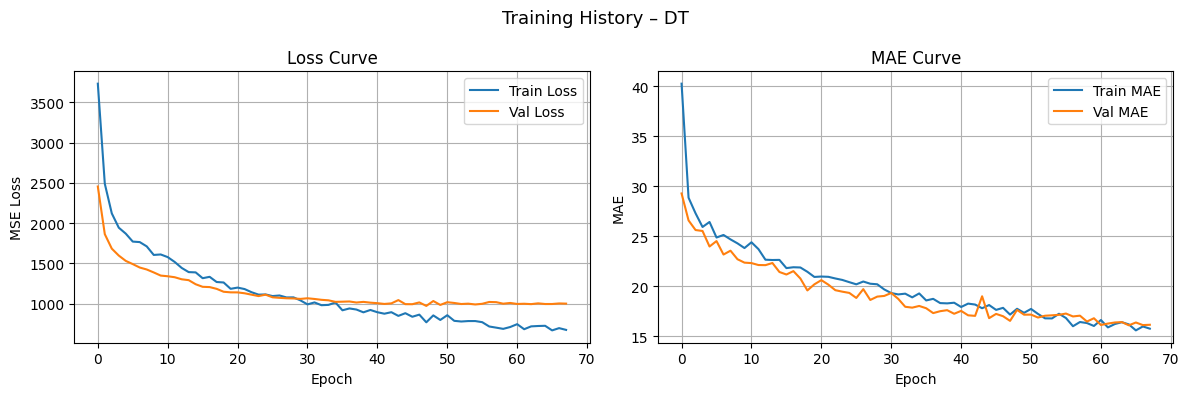

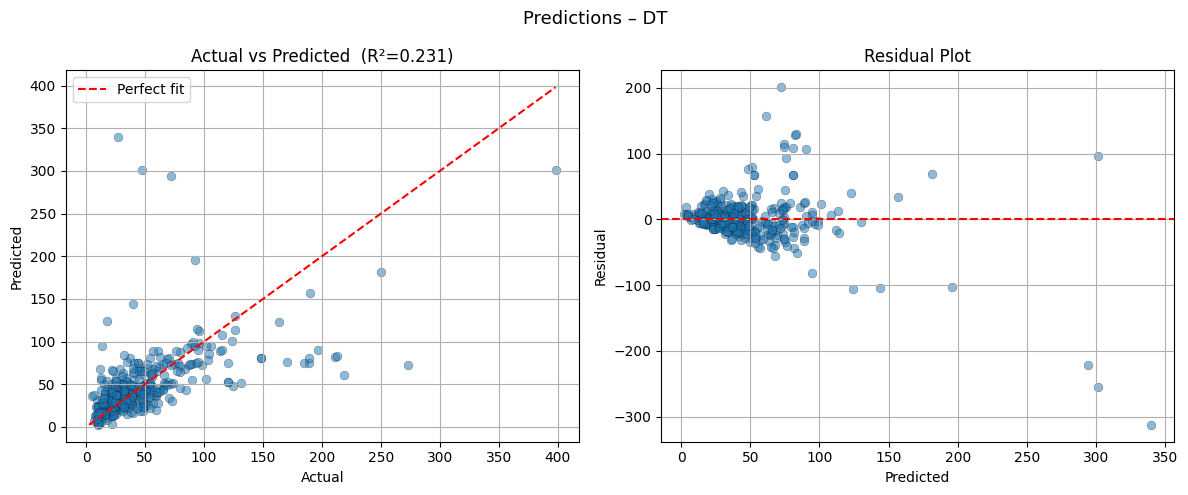

  💾 Model saved: best_model_DT.keras

############################################################
  TARGET: Friability  (FR)
############################################################
  ✅ Target column detected: 'FRIABILITY'
  Features : 69
  Train    : 1585 samples
  Test     : 397 samples

  KerasTuner Search → FR
Search space summary
Default search space size: 7
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'elu', 'tanh'], 'ordered': False}
dropout (Boolean)
{'default': False, 'conditions': []}
batch_norm (Boolean)
{'default': False, 'conditions': []}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
l2_reg (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None

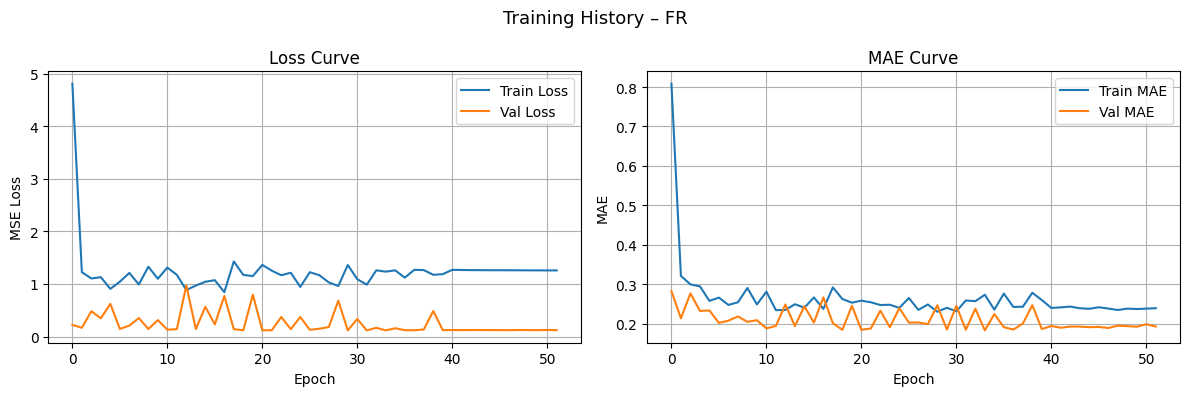

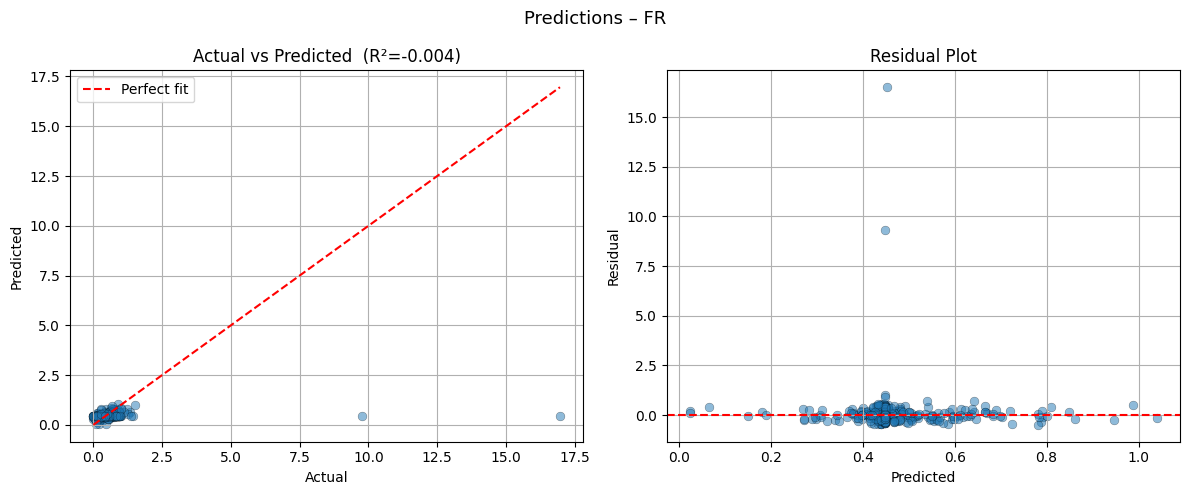

  💾 Model saved: best_model_FR.keras

############################################################
  TARGET: Water_Absorption_Ratio  (WAR)
############################################################
  ✅ Target column detected: 'Water absorption ratio'
  Features : 69
  Train    : 1585 samples
  Test     : 397 samples

  KerasTuner Search → WAR
Search space summary
Default search space size: 7
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'elu', 'tanh'], 'ordered': False}
dropout (Boolean)
{'default': False, 'conditions': []}
batch_norm (Boolean)
{'default': False, 'conditions': []}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
l2_reg (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
unit

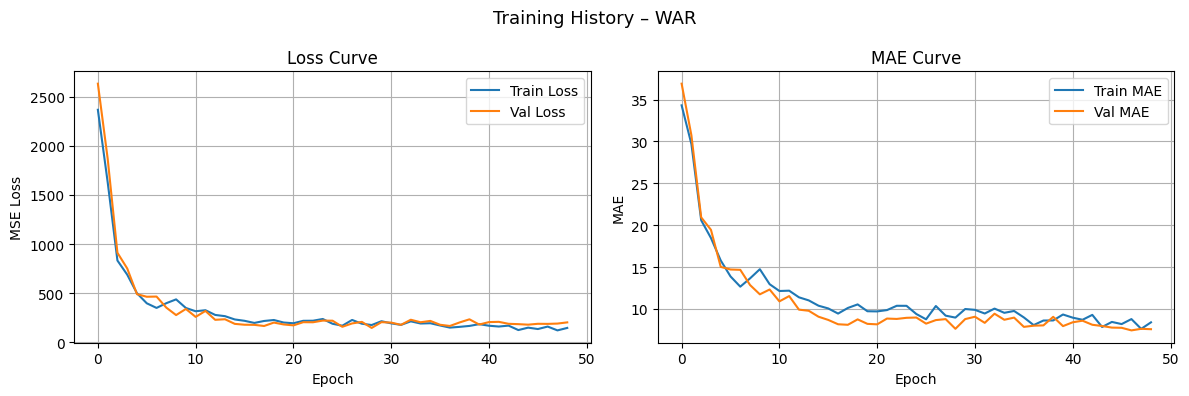

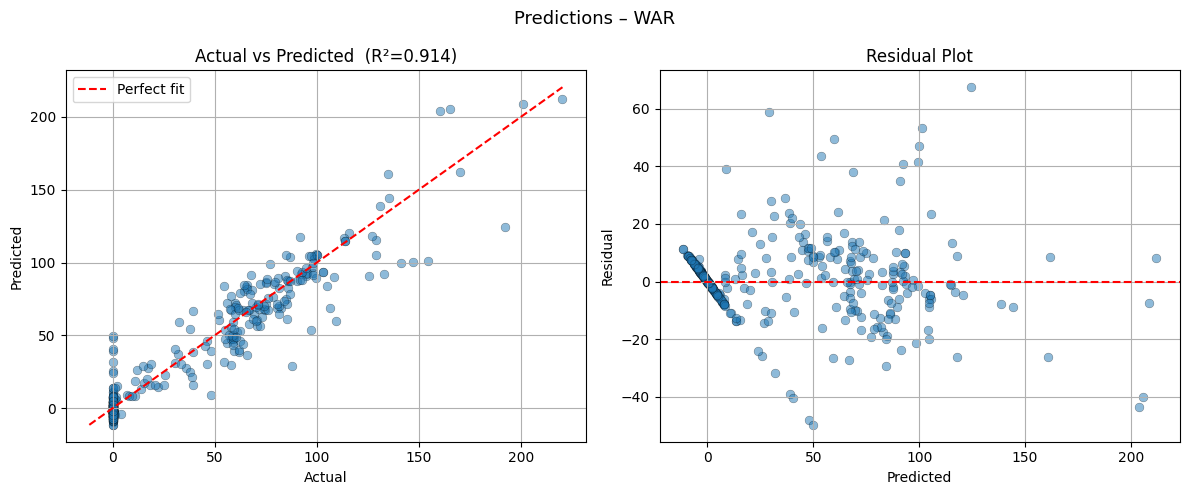

  💾 Model saved: best_model_WAR.keras


  FINAL RESULTS
  DT    → RMSE: 37.4085  |  R²: 0.2312
  FR    → RMSE: 0.9823  |  R²: -0.0041
  WAR   → RMSE: 13.0528  |  R²: 0.9138


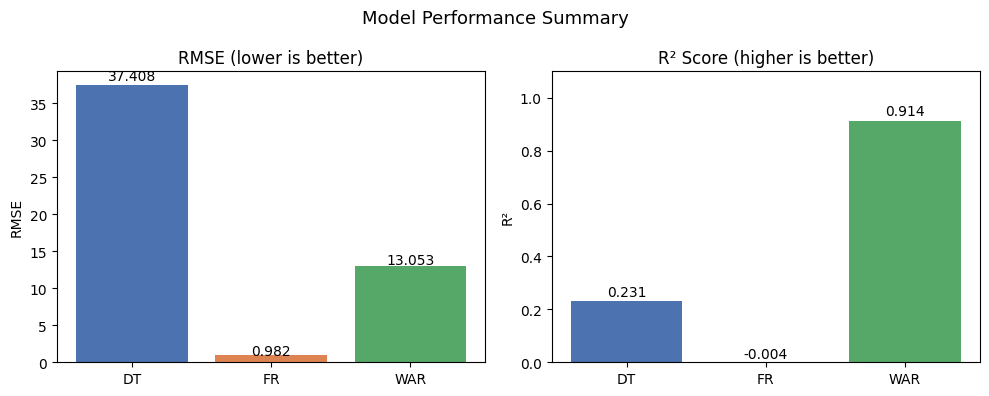

In [15]:
def main():
    # ── Load ──────────────────────────────────
    df = load_data(DATA_PATH)
    explore_data(df)

    results = {}

    for full_name, short in TARGETS.items():
        print(f"\n{'#'*60}")
        print(f"  TARGET: {full_name}  ({short})")
        print(f"{'#'*60}")

        # ── Find target column in dataset ──────
        # The dataset may use different column spellings; adjust this list if needed
        candidates = {
            "Disintegration_Time": ["DISINTEGRATION_TIME"],
            "Friability":          ["FRIABILITY"],
            "Water_Absorption_Ratio": ["Water absorption ratio"],
        }[full_name]

        target_col = identify_target_column(df, candidates)
        if target_col is None:
            print(f"  ⚠️  Could not auto-detect column for {full_name}.")
            print(f"  → Available columns: {df.columns.tolist()}")
            print(f"  → Please set target_col manually and re-run.")
            continue

        print(f"  ✅ Target column detected: '{target_col}'")

        # ── Pre-process ────────────────────────
        X_train, X_test, y_train, y_test, scaler = preprocess(df, target_col)

        # ── Tune + Train ───────────────────────
        best_model, tuner, history = run_tuner(
            X_train, y_train, input_dim=X_train.shape[1], target_name=short
        )

        # ── Evaluate ───────────────────────────
        rmse, r2, y_pred = evaluate_model(best_model, X_test, y_test, full_name)

        # ── Plots ──────────────────────────────
        plot_training_history(history, short)
        plot_predictions(y_test, y_pred, short, r2)

        # ── Save model ─────────────────────────
        best_model.save(f"best_model_{short}.keras")
        print(f"  💾 Model saved: best_model_{short}.keras")

        results[short] = {"RMSE": rmse, "R2": r2}

    # ── Summary ───────────────────────────────
    print("\n\n" + "="*60)
    print("  FINAL RESULTS")
    print("="*60)
    for name, metrics in results.items():
        print(f"  {name:5s} → RMSE: {metrics['RMSE']:.4f}  |  R²: {metrics['R2']:.4f}")

    if results:
        plot_results_summary(results)


if __name__ == "__main__":
    main()